<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_4/LR_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from typing import Tuple

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

class MarkovChainAnalyzer:
    """
    Математичне ядро для аналізу дискретних ланцюгів Маркова.
    Забезпечує матричне множення для динаміки переходів та розв'язання
    систем лінійних алгебраїчних рівнянь (СЛАР) для пошуку стаціонарних ймовірностей.
    """

    @staticmethod
    def calculate_dynamics(P0: np.ndarray, M: np.ndarray, steps: int) -> pd.DataFrame:
        """
        Обчислює ймовірності станів для кожного кроку k за формулою P(k) = P(0) * M^k.
        """
        history = [P0]
        current_P = P0
        for _ in range(1, steps + 1):
            current_P = np.dot(current_P, M)
            history.append(current_P)
        return pd.DataFrame(history)

    @staticmethod
    def get_stationary_probabilities(M: np.ndarray) -> np.ndarray:
        """
        Аналітичний пошук фінальних (стаціонарних) ймовірностей.
        Розв'язує систему: P * M = P  =>  P * (M - I) = 0, за умови sum(P) = 1.
        """
        n = M.shape[0]
        # Формування матриці коефіцієнтів (M - I)^T
        A = (M - np.eye(n)).T

        # Заміна останнього рівняння на умову нормування: сума ймовірностей = 1
        A[-1] = np.ones(n)
        B = np.zeros(n)
        B[-1] = 1.0

        # Розв'язання СЛАР (A * P^T = B)
        stationary_P = np.linalg.solve(A, B)
        return stationary_P

---------------------------------------------------------------------------
БЛОК 1: Ініціалізація Марковської моделі (Верстат з ЧПК - Варіант 15)
---------------------------------------------------------------------------
Матриця перехідних ймовірностей (M):


,S1 (Штатна робота),S2 (Знос інструменту),S3 (Техобслуговування),S4 (Аварія)
S1 (Штатна робота),0.8000,0.1500,0.0000,0.0500
S2 (Знос інструменту),0.0000,0.6000,0.3000,0.1000
S3 (Техобслуговування),0.9500,0.0000,0.0500,0.0000
S4 (Аварія),0.8000,0.0000,0.0000,0.2000


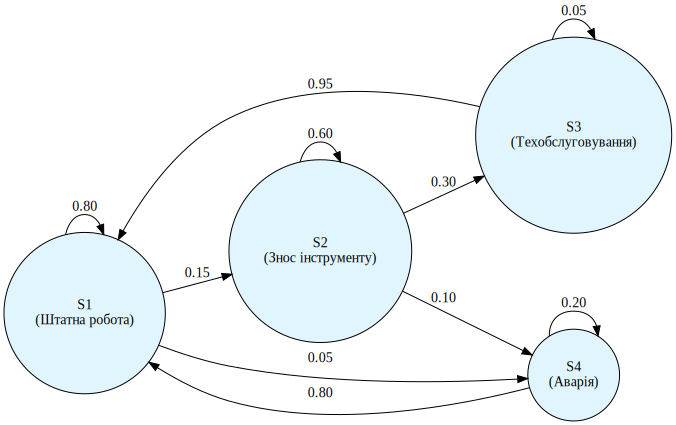

In [2]:
# Завдання 1-2: Визначення станів системи та матриці перехідних ймовірностей
print("-" * 75)
print("БЛОК 1: Ініціалізація Марковської моделі (Верстат з ЧПК - Варіант 15)")
print("-" * 75)

# Простір станів системи моніторингу (S)
states = ["S1 (Штатна робота)", "S2 (Знос інструменту)", "S3 (Техобслуговування)", "S4 (Аварія)"]

# Матриця перехідних ймовірностей (M). Сума по кожному рядку дорівнює 1.0.
# Логіка:
# S1: 80% залишається в нормі, 15% переходить у знос, 5% раптова аварія.
# S2: 60% продовжує працювати зі зносом, 30% йде на планове ТО, 10% ламається (аварія).
# S3: 95% повертається в роботу (ТО успішне), 5% помилка налаштування (перехід в аварію).
# S4: 80% успішний ремонт (в S1), 20% складний ремонт (залишається в S4).
transition_matrix = np.array([
    [0.80, 0.15, 0.00, 0.05],
    [0.00, 0.60, 0.30, 0.10],
    [0.95, 0.00, 0.05, 0.00],
    [0.80, 0.00, 0.00, 0.20]
])

# Вектор початкових станів P(0): система починає роботу абсолютно справною
initial_probabilities = np.array([1.0, 0.0, 0.0, 0.0])

df_matrix = pd.DataFrame(transition_matrix, columns=states, index=states)
print("Матриця перехідних ймовірностей (M):")
display(df_matrix)

# Автоматизована побудова зваженого орієнтованого графа станів
dot = graphviz.Digraph(comment='Markov Chain', format='png')
dot.attr(rankdir='LR')

for i, state in enumerate(states):
    dot.node(str(i), state.split(" ")[0] + "\n" + " ".join(state.split(" ")[1:]), shape='circle', style='filled', fillcolor='#e1f5fe')

for i in range(len(states)):
    for j in range(len(states)):
        prob = transition_matrix[i, j]
        if prob > 0:
            dot.edge(str(i), str(j), label=f" {prob:.2f}")

dot.render('markov_chain_graph', view=False)
display(dot)

In [3]:
# Завдання 3: Розрахунок ймовірностей станів на кожному кроці k
print("-" * 75)
print("БЛОК 2: Розрахунок динаміки марковського процесу у часі")
print("-" * 75)

steps = 20 # Кількість кроків моделювання (змін k)

# Обчислення матричних добутків через створене ядро
df_dynamics = MarkovChainAnalyzer.calculate_dynamics(initial_probabilities, transition_matrix, steps)

# Форматування звіту
df_dynamics.columns = states
df_dynamics.index.name = "Крок k"

print(f"Таблиця ймовірностей станів системи P(k) протягом {steps} кроків:")
print("(Еквівалент ручного розрахунку або протягування формул в Excel)")
display(df_dynamics.head(10)) # Виводимо перші 10 кроків
print("...\n")
display(df_dynamics.tail(5))  # Виводимо останні 5 кроків для спостереження збіжності

---------------------------------------------------------------------------
БЛОК 2: Розрахунок динаміки марковського процесу у часі
---------------------------------------------------------------------------
Таблиця ймовірностей станів системи P(k) протягом 20 кроків:
(Еквівалент ручного розрахунку або протягування формул в Excel)


,S1 (Штатна робота),S2 (Знос інструменту),S3 (Техобслуговування),S4 (Аварія)
Крок k,,,,
0,1.0000,0.0000,0.0000,0.0000
1,0.8000,0.1500,0.0000,0.0500
2,0.6800,0.2100,0.0450,0.0650
3,0.6388,0.2280,0.0653,0.0680
4,0.6274,0.2326,0.0717,0.0683
5,0.6247,0.2337,0.0734,0.0683
6,0.6241,0.2339,0.0738,0.0683
7,0.6239,0.2340,0.0739,0.0682
8,0.6239,0.2340,0.0739,0.0682


...



,S1 (Штатна робота),S2 (Знос інструменту),S3 (Техобслуговування),S4 (Аварія)
Крок k,,,,
16,0.6239,0.2340,0.0739,0.0682
17,0.6239,0.2340,0.0739,0.0682
18,0.6239,0.2340,0.0739,0.0682
19,0.6239,0.2340,0.0739,0.0682
20,0.6239,0.2340,0.0739,0.0682


In [4]:
# Завдання 4: Визначення стаціонарного режиму
print("-" * 75)
print("БЛОК 3: Аналітичний пошук стаціонарних ймовірностей (Граничний режим)")
print("-" * 75)

print("Розв'язання системи алгебраїчних рівнянь Колмогорова:")
print("P_стац * M = P_стац  (за умови ∑P_i = 1)")

# Отримання стаціонарних ймовірностей
stationary_probs = MarkovChainAnalyzer.get_stationary_probabilities(transition_matrix)

df_stationary = pd.DataFrame([stationary_probs], columns=states, index=["Фінальна ймовірність"])
display(df_stationary)

print("\nВерифікація збіжності:")
last_step_probs = df_dynamics.iloc[-1].values
max_diff = np.max(np.abs(last_step_probs - stationary_probs))

if max_diff < 0.001:
    print(f"Підтверджено: Динамічний процес зійшовся до стаціонарного (Макс. похибка: {max_diff:.6f}).")
else:
    print("Увага: Система не досягла стаціонарного режиму. Необхідно збільшити кількість кроків k.")

---------------------------------------------------------------------------
БЛОК 3: Аналітичний пошук стаціонарних ймовірностей (Граничний режим)
---------------------------------------------------------------------------
Розв'язання системи алгебраїчних рівнянь Колмогорова:
P_стац * M = P_стац  (за умови ∑P_i = 1)


,S1 (Штатна робота),S2 (Знос інструменту),S3 (Техобслуговування),S4 (Аварія)
Фінальна ймовірність,0.6239,0.2340,0.0739,0.0682



Верифікація збіжності:
Підтверджено: Динамічний процес зійшовся до стаціонарного (Макс. похибка: 0.000000).


---------------------------------------------------------------------------
БЛОК 4: Графічна інтерпретація результатів
---------------------------------------------------------------------------


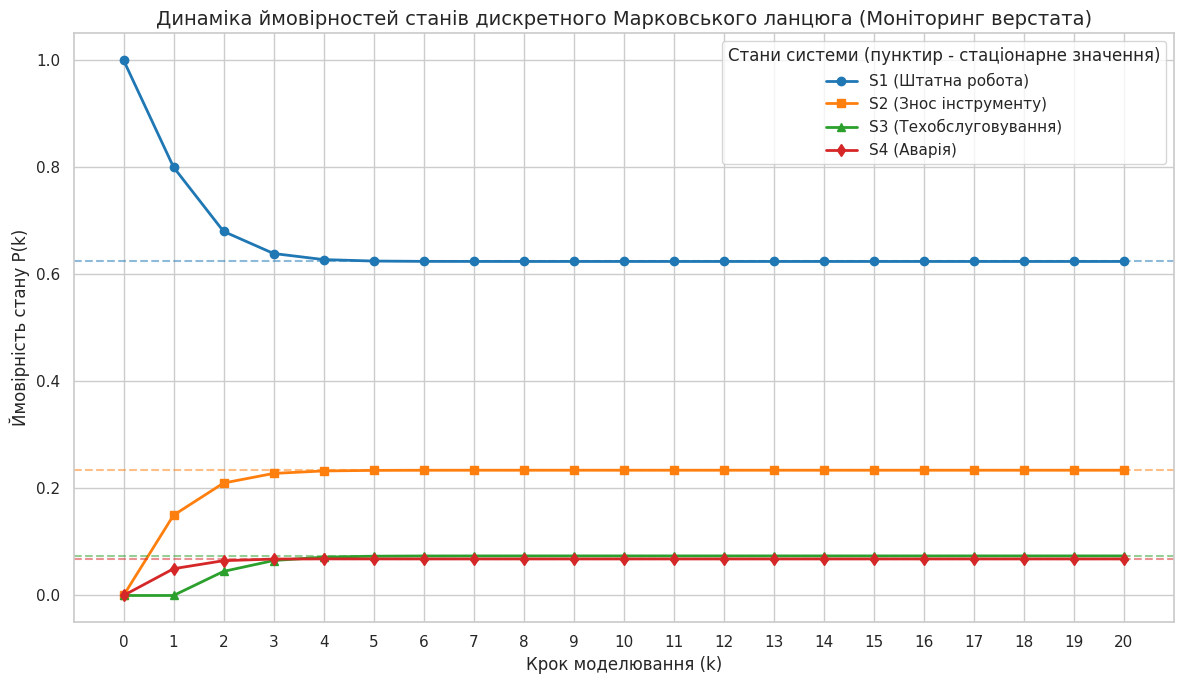


Інтерпретація графіків для систем моніторингу:
1. На початкових етапах (k=1..5) система проходить через 'перехідний процес' - стрімка зміна ймовірностей.
2. Після k=10 ймовірності стабілізуються, наближаючись до своїх асимптот (пунктирні лінії).
3. У сталому режимі обладнання перебуватиме у штатному стані (S1) приблизно 62.4% робочого часу.


In [5]:
# Завдання 5: Побудова графіків ймовірностей станів
print("-" * 75)
print("БЛОК 4: Графічна інтерпретація результатів")
print("-" * 75)

plt.figure(figsize=(12, 7))

# Побудова ліній тренду для кожного стану
markers = ['o', 's', '^', 'd']
for i, state in enumerate(states):
    plt.plot(df_dynamics.index, df_dynamics[state], marker=markers[i], linewidth=2, markersize=6, label=state)

    # Додавання горизонтальних пунктирних ліній для стаціонарних значень
    plt.axhline(stationary_probs[i], color=plt.gca().lines[-1].get_color(), linestyle='--', alpha=0.5)

plt.title('Динаміка ймовірностей станів дискретного Марковського ланцюга (Моніторинг верстата)', fontsize=14)
plt.xlabel('Крок моделювання (k)', fontsize=12)
plt.ylabel('Ймовірність стану P(k)', fontsize=12)
plt.xticks(np.arange(0, steps + 1, step=1))
plt.ylim(-0.05, 1.05)
plt.legend(title="Стани системи (пунктир - стаціонарне значення)")
plt.tight_layout()
plt.show()

print("\nІнтерпретація графіків для систем моніторингу:")
print("1. На початкових етапах (k=1..5) система проходить через 'перехідний процес' - стрімка зміна ймовірностей.")
print("2. Після k=10 ймовірності стабілізуються, наближаючись до своїх асимптот (пунктирні лінії).")
print(f"3. У сталому режимі обладнання перебуватиме у штатному стані (S1) приблизно {stationary_probs[0]*100:.1f}% робочого часу.")